<h2 style="text-align:center; color:#7b2cbf;">
 Customer Shopping Behavior Analysis
</h2>

# 1.Summary

This dataset captures customer shopping behavior in a retail environment, including demographic details (age, gender, age groups), purchasing patterns, product categories, payment methods, shipping preferences, and review ratings. It provides a comprehensive view of how customers interact with products and services, enabling analysis of factors that influence purchase decisions and overall customer engagement.

A leading retail company aims to leverage this data to better understand changes in customer purchasing patterns across different segments and conditions. The key business question is: **"How can the company leverage consumer shopping data to identify trends, improve customer engagement, and optimize marketing and product strategies?"**

# 2.Columns description

- **`Customer ID`** → Unique identifier for each customer  
- **`Age`** → Age of the customer  
- **`Gender`** → Gender of the customer  
- **`Item Purchased`** → Name of the product bought  
- **`Category`** → Product category (Clothing, etc.)  
- **`Purchase Amount (USD)`** → Amount spent on the purchase in USD  
- **`Location`** → Customer's location/state  
- **`Size`** → Size of the purchased item  
- **`Color`** → Color of the product  
- **`Season`** → Season when purchase was made  
- **`Review Rating`** → Rating given by the customer  
- **`Subscription Status`** → Whether customer has subscription (Yes/No)  
- **`Shipping Type`** → Type of shipping selected  
- **`Discount Applied`** → Indicates if discount was applied  
- **`Promo Code Used`** → Whether promo code was used  
- **`Previous Purchases`** → Number of past purchases  
- **`Payment Method`** → Mode of payment (Cash, Card, etc.)  
- **`Frequency of Purchases`** → How often the customer makes purchases  

# 3.Import libraries

In [1]:
import numpy as np
import pandas as pd

# 4.Load data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/bulent1025/customer-shopping-behavior/customer_shopping_behavior.csv')
df.head(3)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly


# 5.Data Preprocessing

## Handled missing values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [5]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x : x.fillna(x.median()))

In [6]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## convert in lower case

In [7]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns = {'purchase_amount_(usd)':'purchase_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## Add new column

In [8]:
#create a new column
labels = ['young_adult','adult','middle_aged','senior']
df['age_groups'] = pd.qcut(df['age'] , q = 4 , labels = labels)
df[['age' , 'age_groups']].head(10)

,age,age_groups
0,55,middle_aged
1,19,young_adult
2,50,middle_aged
3,21,young_adult
4,45,middle_aged
5,46,middle_aged
6,63,senior
7,27,young_adult
8,26,young_adult
9,57,middle_aged


In [9]:
# create column purchase_frequency_days

frequency_mapping = {
    'Fortnightly':14,
    'Weekly':7,
    'Monthly':30,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Annually' :365,
    'Every 3 Months':90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)
df[['frequency_of_purchases','purchase_frequency_days']]

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
...,...,...
3895,Weekly,7
3896,Bi-Weekly,14
3897,Quarterly,90
3898,Weekly,7


In [10]:
df[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [11]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

## drop `promc_code_used` column

In [12]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_groups', 'purchase_frequency_days'],
      dtype='object')

In [13]:
df.to_csv("customers.csv", index=False, encoding="utf-8")

# 6.Exploratory Data Analysis (EDA)

In [18]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_groups,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle_aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young_adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle_aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young_adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle_aged,365


In [14]:
df.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,89.133077
std,1125.977353,15.207589,23.685392,0.713590,14.447125,119.037566
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,14.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,30.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,90.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,365.000000


In [19]:
df['customer_id'].count()

np.int64(3900)

In [35]:
avg_purchase = df["purchase_amount"].mean()
print("Average Purchase Amount:", avg_purchase)

Average Purchase Amount: 59.76435897435898


In [36]:
avg_rating = df["review_rating"].mean()
print("Average Rating:", avg_rating)

Average Rating: 3.750051282051282


In [37]:
gender_count = df["gender"].value_counts()
print(gender_count)

gender
Male      2652
Female    1248
Name: count, dtype: int64


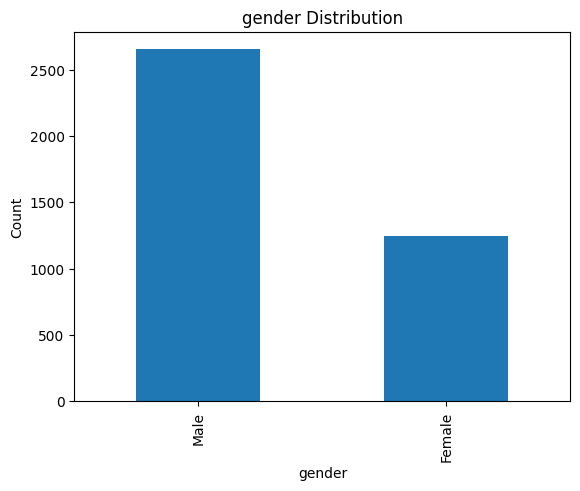

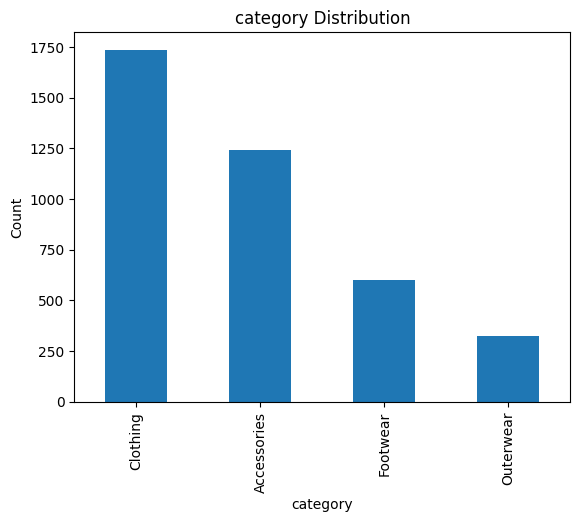

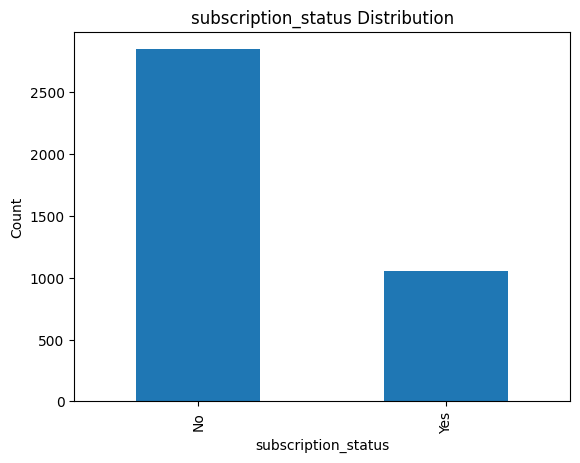

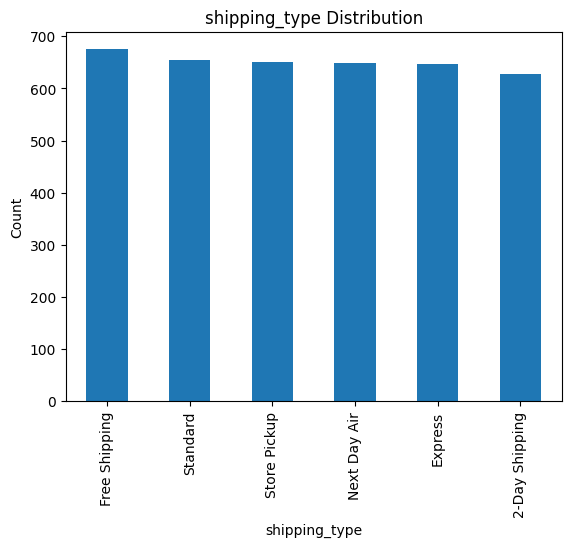

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ["gender", "category", "subscription_status", "shipping_type"]

for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

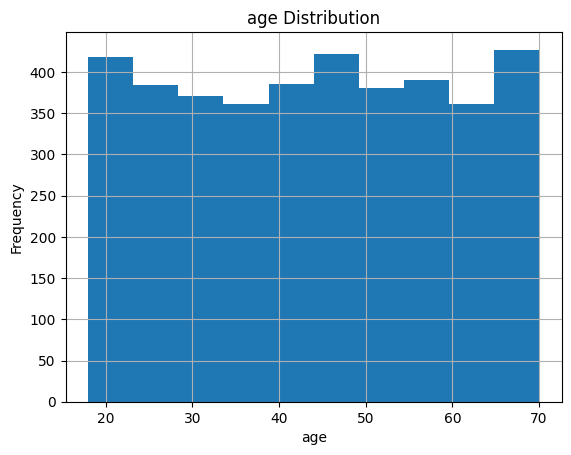

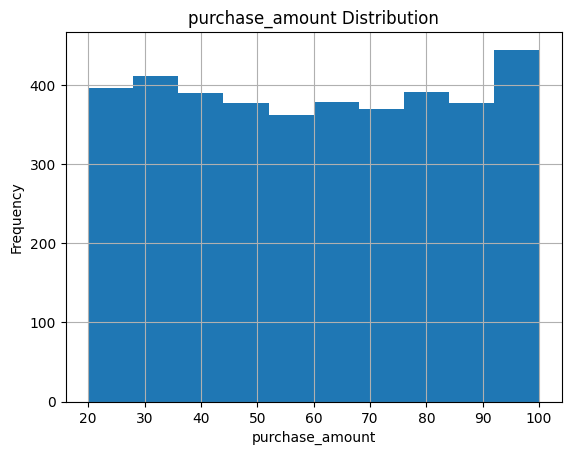

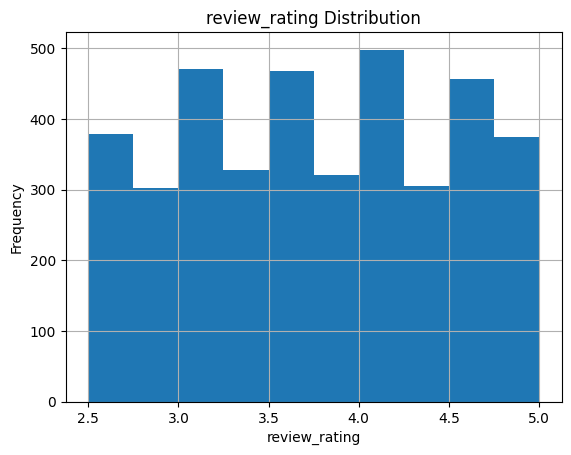

In [21]:
numerical_cols = ["age", "purchase_amount", "review_rating"]

for col in numerical_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

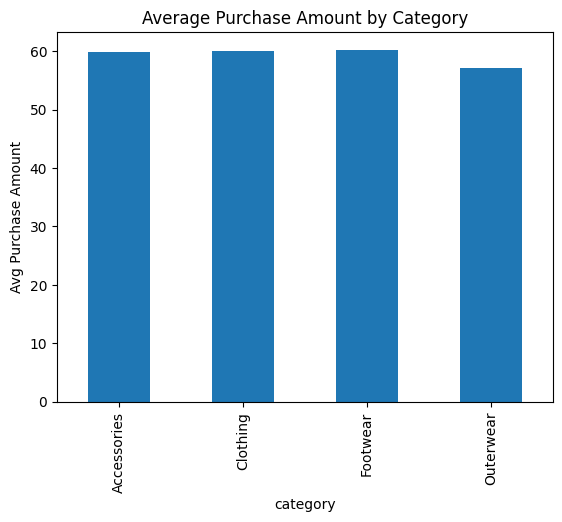

In [22]:
plt.figure()
df.groupby("category")["purchase_amount"].mean().plot(kind='bar')
plt.title("Average Purchase Amount by Category")
plt.ylabel("Avg Purchase Amount")
plt.show()

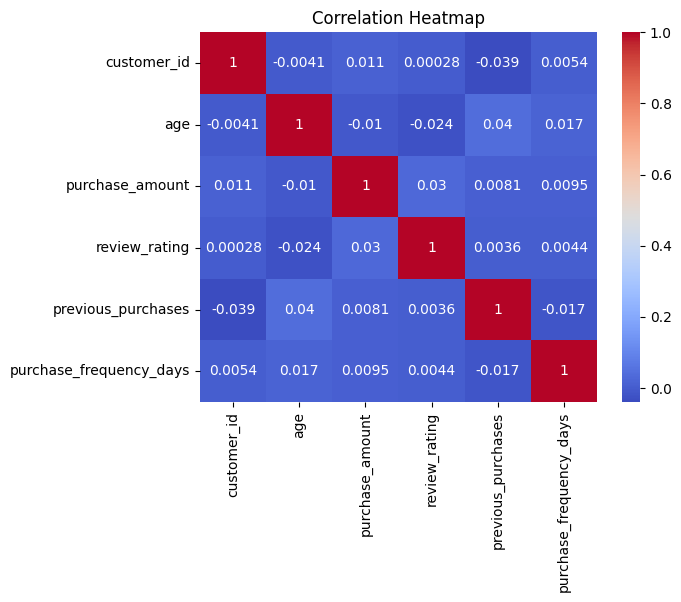

In [25]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

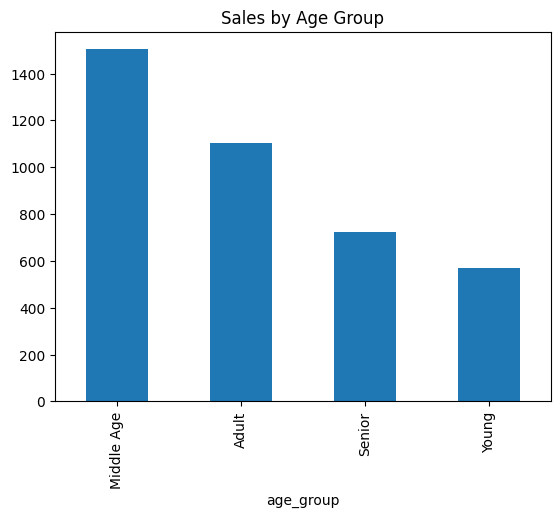

In [28]:
plt.figure()
df["age_group"] = pd.cut(df["age"], bins=[0,25,40,60,100],
                         labels=["Young","Adult","Middle Age","Senior"])

df["age_group"].value_counts().plot(kind='bar')
plt.title("Sales by Age Group")
plt.show()

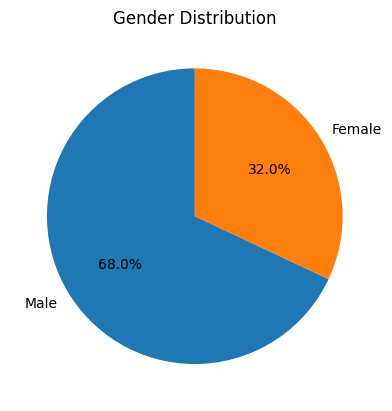

In [38]:
import matplotlib.pyplot as plt

plt.figure()

df["gender"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")  # removes default label

plt.show()

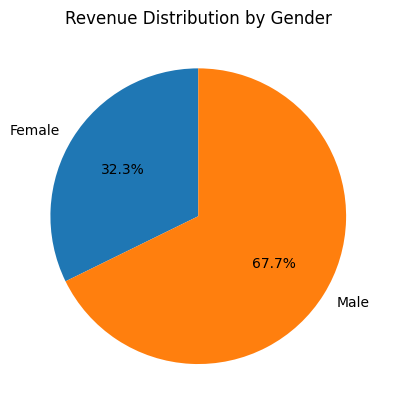

In [31]:
import matplotlib.pyplot as plt

plt.figure()

df.groupby("gender")["purchase_amount"].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Distribution by Gender")
plt.ylabel("")  # removes extra label
plt.show()

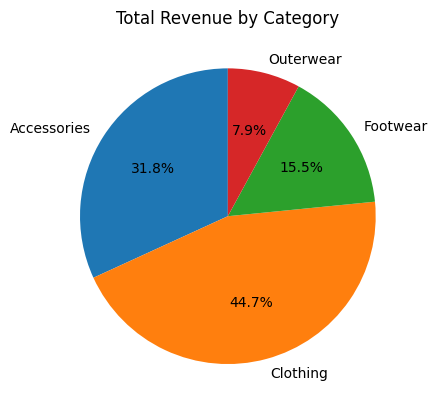

In [30]:
plt.figure()

df.groupby("category")["purchase_amount"].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Total Revenue by Category")
plt.ylabel("")  # removes default ylabel
plt.show()

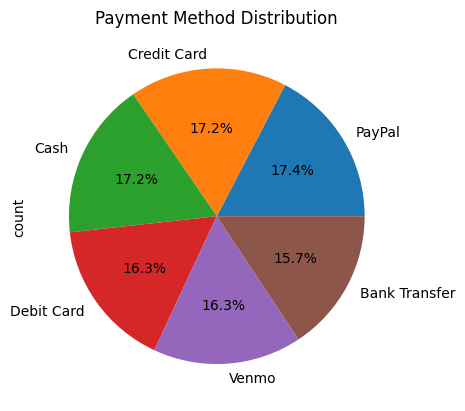

In [29]:
plt.figure()
df["payment_method"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

# 7.Key Findings

1.clothing category has highest number of sale(most saled product).

2.Male and female customers contribute almost equally in terms of both count and revenue.

3.Majority of customers are non-subscribers, indicating lower subscription adoption.

4.Age distribution is fairly uniform across all age groups, showing no strong age concentration.

5.Purchase amount is evenly distributed without extreme skewness, indicating consistent spending behavior.

6.Review ratings are mostly high (around 3–5 range), suggesting overall positive customer satisfaction.

7.Average purchase amount is similar across all categories, indicating balanced pricing across products.

8.Correlation between features is very weak, meaning variables are largely independent.

9.Middle-aged customers contribute the highest number of purchases, making them the most active segment.

10.Revenue is dominated by a few categories, with clothing contributing the largest share.

11.Payment methods are almost equally distributed, showing no strong customer preference for a single method.


# 8.Strategic Recommendations

* Increase subscription adoption by offering exclusive discounts or loyalty benefits to convert non-subscribers into subscribers.
* Focus marketing efforts on middle-aged customers, as they contribute the highest number of purchases.
* Strengthen high-performing categories like clothing through targeted promotions and inventory expansion.
* Introduce personalized offers and discounts to further boost purchase frequency and customer retention.
* Leverage high customer satisfaction (ratings) in marketing campaigns to build trust and attract new customers.
* Use multi-payment support strategies, as customers show no strong preference for a single payment method.
* Implement targeted campaigns across all age groups, since customer distribution is fairly uniform